<a href="https://colab.research.google.com/github/Alhmmada/Bike-Sharing-Demand-Prediction/blob/main/Traffic_Sentiment_Analysis_Assignment_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Traffic Sentiment Analysis

This notebook extends Exercise 4 by comparing three text-vectorization methods and tuning six machine-learning classifiers. The task is binary classification:

- **Input:** traffic-related text in the `Text` column
- **Output:** sentiment label (`0 = Positive`, `1 = Negative`)

Model selection is performed only on the training set using stratified 5-fold cross-validation. The held-out test set is used once for the final evaluation.

Run the code cells from top to bottom. If imports fail, uncomment the installation command in the first code cell and run it. Saved outputs are from the reviewed run. Replace the GitHub placeholder before submitting the forum draft.


In [1]:
# Run once if packages are missing.
# %pip install pandas numpy matplotlib seaborn scikit-learn xgboost


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.naive_bayes import BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from xgboost import XGBClassifier

RANDOM_STATE = 0
from sklearn.base import clone
import sklearn, xgboost
print("scikit-learn:", sklearn.__version__, "XGBoost:", xgboost.__version__)


scikit-learn: 1.6.1 XGBoost: 3.4.1


## 1. Load and prepare the data

Source: the CSV linked in Exercise 4. The three new comments in step 6 are manually written examples, not training records.

Reviewed data SHA-256: `7419e9389554a194114028977bffe785705af074d9ff7a3959e28123c6d1b55b`.


In [3]:
url = "https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_4_Text_classification/Pakistani%20Traffic%20sentiment%20Analysis.csv"
df = pd.read_csv(url)

print("Original shape:", df.shape)
display(df.head())
df.info()

Original shape: (2109, 2)


,Text,Sentiment
0,Adayala road is clear,0
1,Traffic jam from parbat rd to nazim-ud-din rd ...,1
2,Mandra is clear,0
3,Fort street is clear,0
4,"Mashriq Hotel towards Fawara Chowk, City Sadda...",1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2109 entries, 0 to 2108
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Text       2109 non-null   object
 1   Sentiment  2109 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 33.1+ KB


In [4]:
# Remove missing/blank texts, exact duplicates, and ambiguous labels.
print("Missing values before cleaning:")
print(df[["Text", "Sentiment"]].isna().sum())
df = df.dropna(subset=["Text", "Sentiment"]).copy()
df = df[df["Text"].str.strip().ne("")]
assert df["Sentiment"].isin([0, 1]).all()
print("Exact duplicate rows removed:", df.duplicated().sum())
df = df.drop_duplicates()
label_counts = df.groupby("Text")["Sentiment"].nunique()
conflicting_texts = label_counts[label_counts > 1].index
print("Texts with conflicting labels:", len(conflicting_texts))
display(df[df["Text"].isin(conflicting_texts)])
# Do not guess which label is correct: exclude both versions before splitting.
df = df[~df["Text"].isin(conflicting_texts)].reset_index(drop=True)
print("Shape after cleaning:", df.shape)
display(df["Sentiment"].value_counts().sort_index().rename("Count").to_frame())


Missing values before cleaning:
Text         0
Sentiment    0
dtype: int64
Exact duplicate rows removed: 22
Texts with conflicting labels: 4


,Text,Sentiment
12,There is no land sliding happen on road,0
217,Booni to Mastuj road is clear for traffic afte...,0
606,Peshawar Mor is clear for traffic,0
819,Peshawar Mor is clear for traffic,1
866,There is no land sliding happen on road,1
958,Booni to Mastuj road is clear for traffic afte...,1
984,Sawat motorway is clear for all kind of traffic,0
1786,Sawat motorway is clear for all kind of traffic,1


Shape after cleaning: (2079, 2)


,Count
Sentiment,
0,1004
1,1075


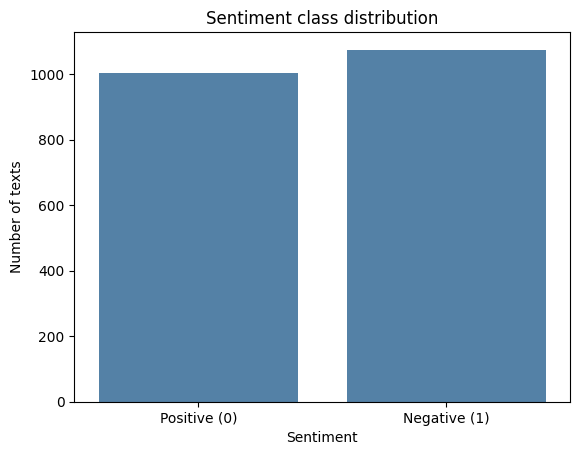

In [5]:
sns.countplot(data=df, x="Sentiment", color="steelblue")
plt.xticks([0, 1], ["Positive (0)", "Negative (1)"])
plt.title("Sentiment class distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of texts")
plt.show()

## 2. Training and testing settings

The data is divided into 80% training data and 20% testing data. `stratify=y` preserves the class distribution. A stratified 5-fold cross-validation procedure is used inside the training set. Accuracy is the Grid Search scoring metric, matching Exercise 4. Precision, recall, and F1-score are also reported for the final model.

The vectorizer is included inside each pipeline. This ensures that it is fitted only on the relevant training folds and avoids data leakage.

These CV scores are used for model selection, so the winning CV score can be optimistic. The held-out test score is the separate final evaluation; this is not nested cross-validation. Vectorizers are screened using Logistic Regression, then classifiers are tuned using the selected representation. This does not search every vectorizer/classifier combination.


In [6]:
X = df["Text"]
y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1663
Testing samples: 416


## 3. Compare text-vectorization methods

In [7]:
vectorizers = {
    "CountVectorizer": CountVectorizer(
        ngram_range=(1, 2), stop_words="english", min_df=2
    ),
    "HashingVectorizer": HashingVectorizer(
        ngram_range=(1, 2), stop_words="english", n_features=2048,
        alternate_sign=False
    ),
    "TfidfVectorizer": TfidfVectorizer(
        ngram_range=(1, 2), stop_words="english", min_df=2
    ),
}

vectorizer_rows = []

for name, vectorizer in vectorizers.items():
    pipeline = Pipeline([
        ("vectorizer", vectorizer),
        ("classifier", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    scores = cross_val_score(
        pipeline, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=1
    )
    vectorizer_rows.append({
        "Vectorizer": name,
        "Mean CV accuracy": scores.mean(),
        "CV standard deviation": scores.std(),
    })

vectorizer_results = pd.DataFrame(vectorizer_rows).sort_values(
    "Mean CV accuracy", ascending=False
).reset_index(drop=True)
display(vectorizer_results.round(4))

,Vectorizer,Mean CV accuracy,CV standard deviation
0,TfidfVectorizer,0.9753,0.0113
1,CountVectorizer,0.9693,0.0075
2,HashingVectorizer,0.9597,0.0107


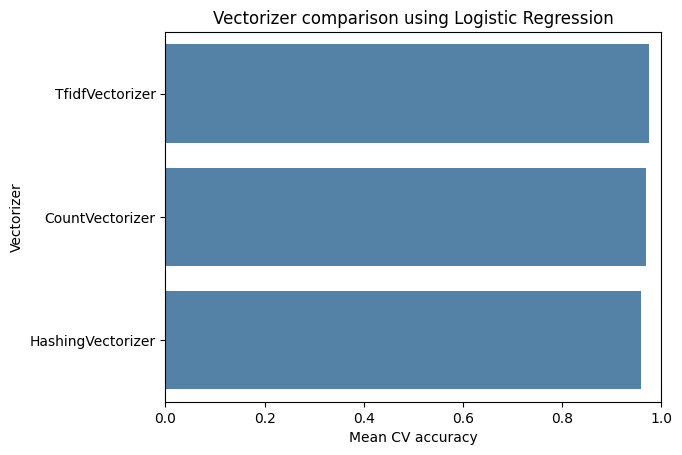

In [8]:
sns.barplot(data=vectorizer_results, x="Mean CV accuracy", y="Vectorizer", color="steelblue")
plt.xlim(0, 1.00)
plt.title("Vectorizer comparison using Logistic Regression")
plt.show()

The representation with the highest mean CV accuracy in step 3 is selected automatically. All representations use unigrams and bigrams and English stop words. Count and TF-IDF use `min_df=2`; Hashing uses 2,048 features. This compares these specific settings, not all possible settings. Removing English stop words can remove negations such as "not", which is a limitation for sentiment analysis.

## 4. Tune and compare classification models

In [9]:
best_vectorizer_name = vectorizer_results.loc[0, "Vectorizer"]
base_vectorizer = clone(vectorizers[best_vectorizer_name])
print("Selected vectorizer:", best_vectorizer_name)

model_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {
            "classifier__C": [0.1, 1, 10],
            "classifier__class_weight": [None, "balanced"],
        },
    ),
    "KNN": (
        KNeighborsClassifier(),
        {
            "classifier__n_neighbors": [3, 5, 7, 9],
            "classifier__weights": ["uniform", "distance"],
        },
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1),
        {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [None, 20],
            "classifier__min_samples_split": [2, 5],
        },
    ),
    "XGBoost": (
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=1),
        {
            "classifier__n_estimators": [100, 200],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__max_depth": [3, 5],
        },
    ),
    "SVM": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {
            "classifier__kernel": ["linear", "rbf"],
            "classifier__C": [0.1, 1, 10],
        },
    ),
    "Bernoulli Naive Bayes": (
        BernoulliNB(),
        {"classifier__alpha": [0.1, 0.5, 1.0]},
    ),
}

Selected vectorizer: TfidfVectorizer


In [10]:
searches = {}
model_rows = []

for model_name, (classifier, param_grid) in model_grids.items():
    pipeline = Pipeline([
        ("vectorizer", clone(base_vectorizer)),
        ("classifier", classifier),
    ])

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=cv,
        scoring="accuracy",
        n_jobs=1,
        return_train_score=False,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    searches[model_name] = search

    model_rows.append({
        "Model": model_name,
        "Mean CV accuracy": search.best_score_,
        "CV standard deviation": search.cv_results_["std_test_score"][search.best_index_],
        "Best parameters": search.best_params_,
    })

model_results = pd.DataFrame(model_rows).sort_values(
    "Mean CV accuracy", ascending=False
).reset_index(drop=True)

display(model_results.round(4))

,Model,Mean CV accuracy,CV standard deviation,Best parameters
0,Logistic Regression,0.9753,0.0092,"{'classifier__C': 10, 'classifier__class_weigh..."
1,SVM,0.9747,0.0045,"{'classifier__C': 1, 'classifier__kernel': 'li..."
2,Random Forest,0.9729,0.0116,"{'classifier__max_depth': None, 'classifier__m..."
3,XGBoost,0.9675,0.0098,"{'classifier__learning_rate': 0.05, 'classifie..."
4,Bernoulli Naive Bayes,0.9549,0.0162,{'classifier__alpha': 1.0}
5,KNN,0.8599,0.0147,"{'classifier__n_neighbors': 9, 'classifier__we..."


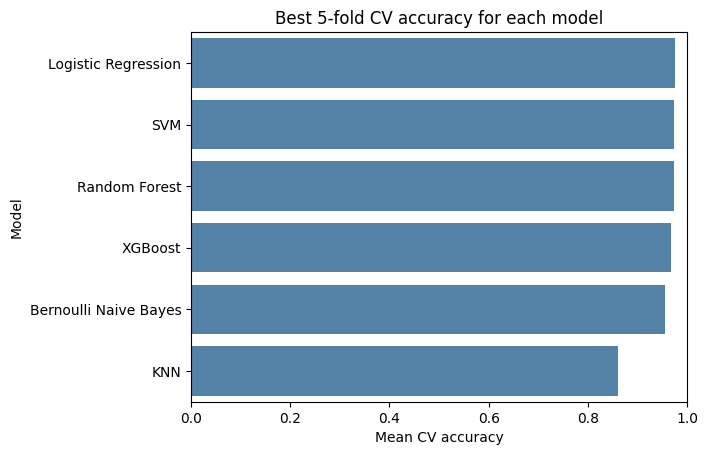

In [11]:
sns.barplot(data=model_results, x="Mean CV accuracy", y="Model", color="steelblue")
plt.xlim(0, 1.00)
plt.title("Best 5-fold CV accuracy for each model")
plt.show()

## 5. Evaluate the selected model on the held-out test set

The model with the highest mean CV accuracy is selected automatically. In this run it is Logistic Regression with `C=10` and `class_weight="balanced"`. Training minimizes class-weighted logistic loss with L2 regularization. `C` controls inverse regularization strength. Grid Search selects parameters using validation accuracy, which is different from the training loss.

BernoulliNB uses its default zero threshold to convert nonnegative vectorized features into word-presence indicators; it does not use the full TF-IDF magnitudes.

In [12]:
best_model_name = model_results.loc[0, "Model"]
best_search = searches[best_model_name]
best_model = best_search.best_estimator_

y_pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print("Best parameters:", best_search.best_params_)
print(f"Best mean 5-fold CV accuracy: {best_search.best_score_:.4f}")
print(f"Held-out test accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification report:")
print(classification_report(
    y_test, y_pred, target_names=["Positive", "Negative"]
))

Best model: Logistic Regression
Best parameters: {'classifier__C': 10, 'classifier__class_weight': 'balanced'}
Best mean 5-fold CV accuracy: 0.9753
Held-out test accuracy: 0.9736

Classification report:
              precision    recall  f1-score   support

    Positive       0.98      0.97      0.97       201
    Negative       0.97      0.98      0.97       215

    accuracy                           0.97       416
   macro avg       0.97      0.97      0.97       416
weighted avg       0.97      0.97      0.97       416



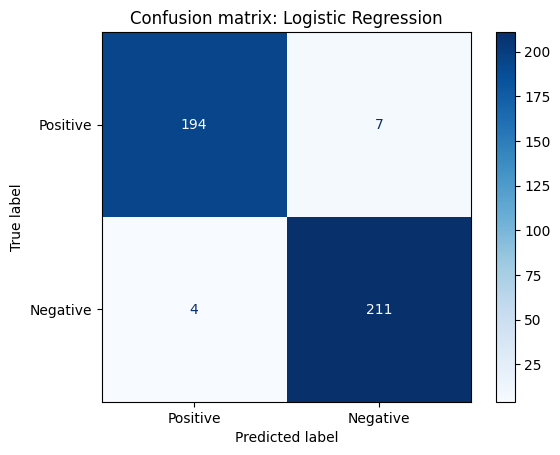

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Positive", "Negative"],
    cmap="Blues",
    values_format="d",
)
plt.title(f"Confusion matrix: {best_model_name}")
plt.show()

## 6. Use the model for new traffic comments

In [14]:
new_comments = [
    "The road is clear and traffic is moving smoothly.",
    "The bus is extremely late and the station is overcrowded.",
    "My train arrived on time and the journey was comfortable.",
]

new_predictions = best_model.predict(new_comments)
label_names = {0: "Positive", 1: "Negative"}

prediction_table = pd.DataFrame({
    "Text": new_comments,
    "Predicted sentiment": [label_names[int(label)] for label in new_predictions],
})
display(prediction_table)

,Text,Predicted sentiment
0,The road is clear and traffic is moving smoothly.,Positive
1,The bus is extremely late and the station is o...,Negative
2,My train arrived on time and the journey was c...,Negative


## 7. Conclusion

After removing 22 exact duplicate rows and eight rows representing four texts with conflicting labels, 2,079 texts remained. TF-IDF ranked highest in the vectorizer screening. Among the tested classifier settings, Logistic Regression (`C=10`, `class_weight="balanced"`) achieved the highest mean five-fold CV accuracy: 97.53%, with a fold standard deviation of 0.92 percentage points. Linear SVM scored 97.47%; the difference is too small to establish a clear general advantage.

The selected model classified 405 of 416 test texts correctly (97.36% accuracy). The held-out split was excluded from fitting and parameter selection in this corrected run. These are updated results after a data-quality correction, not a new external validation dataset. CV scores were used for selection and may be optimistic. This study uses one split and a limited grid, so it does not identify a universally best classifier.

The clearly positive train example was classified as negative. This illustrates that high aggregate accuracy does not guarantee correct predictions for new wording. The cause cannot be established from this one example. English stop-word removal can discard negations; near-duplicate wording and geographic coverage are further limitations. Future work could evaluate preserved negations and external transport data.

Revision note: this version supersedes the earlier 2,087-row analysis (SVM, 97.06% CV and 97.37% test). Use the new results consistently in the forum post. The data correction was based on conflicting labels, not on trying to improve test accuracy.